In [1]:
import tensorflow as tf 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [2]:
data = tf.keras.datasets.fashion_mnist.load_data()
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [3]:
(train_images, train_labels), (test_images, test_labels) = data


In [4]:
print("Train Images:", train_images.shape)
print("Train Labels:", train_labels.shape)
print("Test Images:", test_images.shape)
print("Test Labels:", test_labels.shape)

Train Images: (60000, 28, 28)
Train Labels: (60000,)
Test Images: (10000, 28, 28)
Test Labels: (10000,)


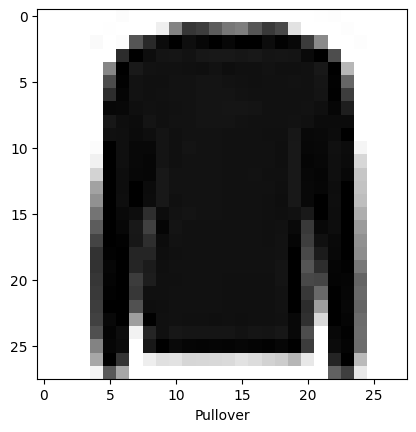

In [5]:
rndm = np.random.randint(0, len(train_images))
plt.xlabel(classes[train_labels[rndm]])
plt.imshow(train_images[rndm], cmap=plt.cm.binary)

In [6]:
train_images = train_images.astype(np.float32) / 255.0
test_images = test_images.astype(np.float32) / 255.0

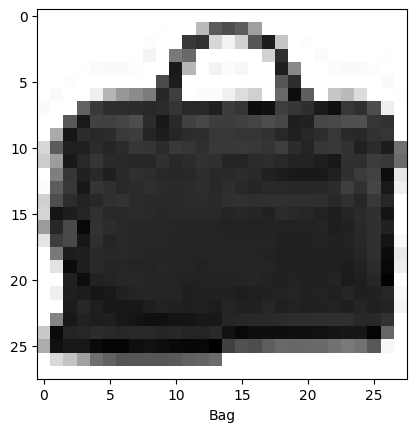

In [7]:
rndm = np.random.randint(0, len(train_images))
plt.xlabel(classes[train_labels[rndm]])
plt.imshow(train_images[rndm], cmap=plt.cm.binary)

In [8]:
print("pixel_value:")
for row in train_images[rndm]:
    for pixel in row:
        print("{:0.3f}".format(pixel), end=" ")
    print()

pixel_value:
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.004 0.000 0.000 0.271 0.643 0.694 0.639 0.376 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.008 0.000 0.000 0.780 0.804 0.157 0.051 0.180 0.663 0.886 0.227 0.000 0.008 0.000 0.000 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.043 0.000 0.525 0.588 0.000 0.000 0.000 0.000 0.000 0.169 0.816 0.000 0.000 0.016 0.000 0.000 0.000 0.000 0.004 0.000 
0.000 0.000 0.000 0.004 0.016 0.020 0.020 0.008 0.000 0.000 0.898 0.286 0.000 0.047 0.012 0.031 0.000 0.000 0.882 0.463 0.000 0.000 0.012 0.020 0.020 0.008 0.000 0.000 
0.000 0.000 0.008 0.000 0.000 0.000 0.000 0.000 0.000 0.706 0.886 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.663 0.820 0.000 0.000 0.000 0.00

In [9]:
#reshape images to (28, 28, 1)
train_images = train_images.reshape(-1, 28, 28, 1)
test_images = test_images.reshape(-1, 28, 28, 1)
print(train_images.shape)
print(test_images.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [10]:
#create model


model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(10, activation='softmax')])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,962 (367.04 KB)

 Trainable params: 93,962 (367.04 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.fit(train_images, train_labels, epochs=30, validation_data=(test_images, test_labels))

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8020 - loss: 0.5496 - val_accuracy: 0.8437 - val_loss: 0.4281
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8639 - loss: 0.3748 - val_accuracy: 0.8665 - val_loss: 0.3667
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8823 - loss: 0.3200 - val_accuracy: 0.8770 - val_loss: 0.3424
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8944 - loss: 0.2871 - val_accuracy: 0.8760 - val_loss: 0.3373
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9035 - loss: 0.2622 - val_accuracy: 0.8878 - val_loss: 0.3112
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9119 - loss: 0.2391 - val_accuracy: 0.8946 - val_loss: 0.3038
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9192 - loss: 0.2191 - val_accuracy: 0.8869 - val_loss: 0.3267
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9245 - loss: 0.2030

In [12]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)   

313/313 - 1s - 2ms/step - accuracy: 0.8920 - loss: 0.6345
Test Loss: 0.6344940662384033
Test Accuracy: 0.8920000195503235


In [13]:
predictions = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [14]:
i = np.random.randint(0, len(test_images))
print("Predicted Label:", np.argmax(predictions[i]))
print("Actual Label:", test_labels[i])

Predicted Label: 0
Actual Label: 0


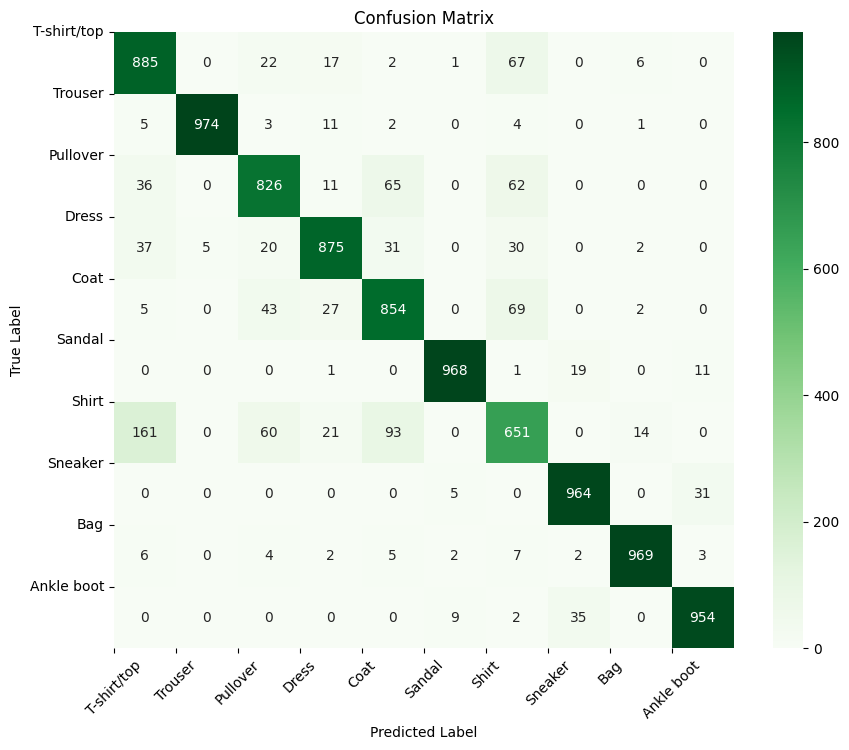

In [15]:

cm = confusion_matrix(test_labels, np.argmax(predictions, axis=1))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(classes)), classes, rotation=45)
plt.yticks(np.arange(len(classes)), classes, rotation=0)
plt.title("Confusion Matrix")
plt.show()

In [16]:
model.save("fashion_mnist_model.keras")